# Visualise Quantum ESPRESSO NEB Outputs

In [38]:
# from ase.neb.NEB import NEBEspresso
from ase.io import iread
from ase.atoms import Atoms
from ase.visualize import view
import subprocess
import scipy.constants as const
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def extract_neb_data(output_file_path, input_file):
    """
    Extract NEB energy and error data from a Quantum ESPRESSO output file.
    
    Parameters:
    -----------
    output_file_path : str
        Path to the NEB output file (.out file)
    
    Returns:
    --------
    dict
        Nested dictionary with structure: {iteration: {image: {'energy': float, 'error': float, 'frozen': bool}}}
        where iteration is the snapshot number and image is the image index (0-based)
    """
    # Find the number of atoms from the input file
    with open(input_file, 'r') as file:
        for line in file:
            if 'nat' in line:
                natoms = int(line.split()[2])
    
    # Use grep to extract energy data from the output file
    result = subprocess.run(["grep", "-A", "12", "energy (eV)", output_file_path], 
                           capture_output=True, text=True)
    energies = result.stdout
    
    # Parse the grep output
    data = {}
    current_snapshot = 0
    
    # Split by the separator lines first
    sections = energies.split('--')
    
    for section in sections:
        lines = section.strip().split('\n')
        
        # Find the header line
        header_found = False
        for line in lines:
            if 'image' in line and 'energy' in line:
                header_found = True
                break
        
        if header_found:
            data[current_snapshot] = {}
            
            # Parse data lines after header
            for line in lines:
                line = line.strip()
                if line and not ('image' in line and 'energy' in line):
                    parts = line.split()
                    if len(parts) >= 4:
                        try:
                            image_num = int(parts[0]) - 1  # Convert to 0-based indexing
                            data[current_snapshot][image_num] = {
                                'energy': float(parts[1]),
                                'error': float(parts[2]),
                                'frozen': parts[3] == 'T'
                            }
                            # Convert energy from Rydberg to meV
                            data[current_snapshot][image_num]['energy'] = data[current_snapshot][image_num]['energy'] * const.value('Rydberg constant times hc in eV')*1000 / natoms
                        except (ValueError, IndexError):
                            pass
            
            current_snapshot += 1
    
    return data

In [3]:
# Define the function to plot the energies of a given iteration
def plot_neb_energies(data, iteration):
    # Get the last set of images
    last_set = list(data.keys())[iteration]
    images = data[last_set]

    # Extract energies and errors
    energies = [images[i]['energy'] for i in range(len(images))]
    print(energies)
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    plt.plot(energies, label='Energy')
    plt.xlabel('Image')
    plt.ylabel('Energy (meV/atom)')
    plt.title(f'NEB Energy Convergence for iteration {iteration}')
    plt.show()

In [4]:
# Define the function to plot the errors and the average error over iterations
def plot_neb_errors(data, start_iteration=0):
    # Extract errors for each iteration
    iteration_errors = []
    iterations = []
    
    # Get all unique image numbers to assign consistent colors
    all_images = set()
    for iteration in data.keys():
        all_images.update(data[iteration].keys())
    all_images = sorted(list(all_images))
    
    # Create color map for each image
    colors = plt.cm.tab10(np.linspace(0, 1, len(all_images)))
    image_colors = {img: colors[i] for i, img in enumerate(all_images)}
    
    # Plot
    plt.figure(figsize=(12, 8))
    
    # Plot individual image errors with connecting lines
    for img in all_images:
        img_iterations = []
        img_errors = []
        
        # Collect data for this specific image across all iterations
        for iteration in sorted(data.keys()):
            if img in data[iteration]:
                img_iterations.append(iteration)
                img_errors.append(data[iteration][img]['error'])
        
        # Plot line connecting this image's errors
        if len(img_iterations) > 1:  # Only plot line if there are multiple points
            plt.plot(img_iterations[start_iteration:], img_errors[start_iteration:], 
                    color=image_colors[img], 
                    linewidth=1.5, alpha=0.7, zorder=1)
        
        # Plot individual points for this image
        plt.scatter(img_iterations[start_iteration:], img_errors[start_iteration:], 
                   color=image_colors[img], 
                   s=50, alpha=0.8, 
                   edgecolors='black', linewidth=0.5, zorder=2)
    
    # Calculate average errors for plotting
    for iteration in sorted(data.keys()):
        image_errors = [data[iteration][image]['error'] 
                       for image in data[iteration].keys()]
        avg_error = np.mean(image_errors)
        iteration_errors.append(avg_error)
        iterations.append(iteration)
    
    # Plot average error per iteration as a thick line
    plt.plot(iterations[start_iteration:], iteration_errors[start_iteration:], 'ko-', linewidth=3, markersize=8,
             label='Average Error per Iteration', zorder=10)
    
    # Create legend for individual images
    legend_elements = []
    for img in all_images:
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                        markerfacecolor=image_colors[img],
                                        markersize=8, label=f'Image {img}'))
    
    # Add the average line to legend
    legend_elements.append(plt.Line2D([0], [0], color='black', linewidth=3, 
                                    label='Average per Iteration'))
    
    plt.xlabel('Iteration')
    plt.ylabel('Error')
    plt.title('NEB Error Convergence - Individual Images and Averages')
    plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# Extract the positions of the atoms in each image for the last iteration and save them as an array
def extract_neb_images(basename, iteration, input_file):
    
    atomic_species = []
    # Read the input file to get the atomic species in order
    with open(input_file, 'r') as file:
        in_section = False
        for line in file:
            if 'ATOMIC_POSITIONS' in line:
                in_section = True
            elif in_section:
                atomic_species.append(line.split()[0])
            if 'LAST_IMAGE' in line:
                break
    atomic_species.pop()
    
    path_file = folder + basename + '/' + basename + '.path' + str(iteration)
    with open(path_file, 'r') as file:
        lines = []
        in_section = False
        
        for line in file:
            if 'QUICK-MIN FIELDS' in line:
                break
            if in_section:
                lines.append(line.rstrip())  # Remove trailing newline
            if 'ENERGIES, POSITIONS AND GRADIENTS' in line:
                in_section = True

    # Parse into structure: [[energy, positions, gradients], ...]
    images = []
    current_image = None
    
    for line in lines:
        if 'Image:' in line:
            # Start of a new image
            if current_image is not None:
                images.append(current_image)
            
            # Initialize new image data
            current_image = [None, [], []]  # [energy, positions, gradients]
            
        elif current_image is not None:
            # Check if this is an energy line
            if line.strip().startswith('-') and '.' in line:
                current_image[0] = float(line.strip())
            
            # Check if this is a position/gradient line
            elif len(line.split()) >= 6:
                parts = line.split()
                try:
                    positions = [float(parts[0]), float(parts[1]), float(parts[2])]
                    gradients = [float(parts[3]), float(parts[4]), float(parts[5])]

                    current_image[1].append(positions)
                    current_image[2].append(gradients)
                except (ValueError, IndexError):
                    pass
    
    # Don't forget the last image
    if current_image is not None:
        images.append(current_image)
    
    # Iterate through the images and add the atomic species to the positions
    for image in images:
        for i in range(len(image[1])):
            image[1][i].insert(0, atomic_species[i])
    return images

In [ ]:
folder = './'
basename = 'neb'
output_file = folder + basename + '/' + basename + '.out'
input_file = 'neb.in'
data = extract_neb_data(output_file, input_file)
last_iteration = len(data) - 1
positions = extract_neb_images(basename, last_iteration, input_file)
print(positions)

[[-1266.4092328797, [[], [['Pt', 3.041010249391, 5.258052662079, 11.701189187331], ['Pt', 7.561698877342, 7.868182914746, 11.70123770038], ['Pt', 1.512774067564, 2.610503906891, 16.114675933509], ['Pt', 4.54079769535, 2.629570821891, 7.292888758786], ['Pt', 7.577614112024, 2.620686117479, 11.701198334739], ['Pt', 6.04944360366, 5.262872448244, 16.111718144005], ['Pt', 4.54624603466, 2.634223615226, 20.534314985442], ['Pt', 9.077127995371, 5.248591176027, 7.292891385694], ['Pt', 9.081777465623, 5.252728123263, 20.534337323517], ['Pt', 6.077984377127, 0.008471116495, 16.113224729859], ['Pt', 9.07703926158, 0.01055884491, 7.236326821908], ['Pt', 9.081702557446, 0.015574916172, 21.028771647235], ['H', 7.376654194989, 2.968275481515, 22.394404930775], ['H', 3.409949540194, 0.016710673887, 22.390832859339], ['H', 11.915824040193, 4.927207215614, 22.391733616193], ['H', 9.079826478735, 0.018090897345, 23.967968741808]]], []], [-1266.4091101767, [[], [['Pt', 3.034683779117, 5.252439342824, 11.

[-83085752.57972583, -83085505.13767898, -83085371.36337487, -83085522.80936547, -83085358.89681843, -83085164.19989404, -83085314.9960087, -83085374.50268447, -83085365.13829407, -83085324.49353081]


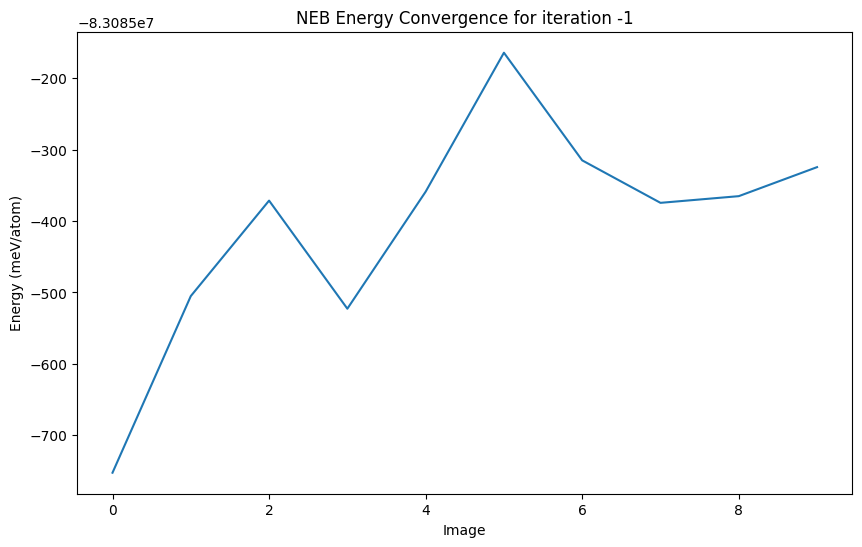

In [ ]:
# Visualise NEB output for original NEB calculation (i.e. moving the on-top H-atom, not allowing first and last images to relax)
data = extract_neb_data(output_file, input_file)
plot_neb_energies(data, -1)

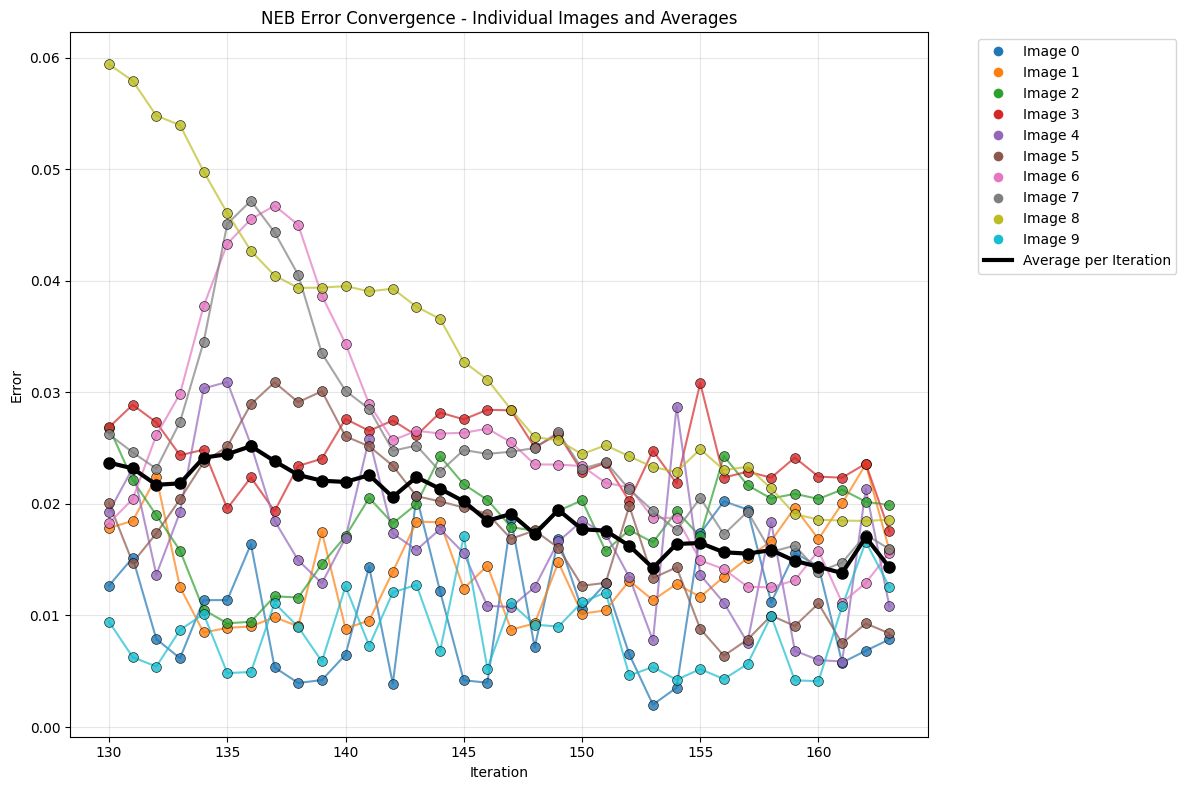

In [8]:
plot_neb_errors(data, 130)

# Extract Atomic Coordinates

Extract final atomic coordinates from basename.crd and plot using x3d viewer.
See if we can create an animation with ngl viewer.

The .crd file is organised as a series of images, with the atomic species then the three numbers that make up the coordinates per line. This code sorts the text file into the following data structure:
Top level: image number
Second level: atom type, coordinate

In [52]:
def extract_crd_data(basename):
    """
    Extract atomic coordinates from NEB coordinate file and organize into nested list structure.
    
    Returns:
    --------
    list: [[[atom_type, [x, y, z]], ...], ...] where outer list is images, 
          middle list is atoms, inner list is [atom_type, [x, y, z]]
    """
    with open(basename + '.crd') as f:
        contents = f.readlines()
    
    # Initialize the data structure
    image_coordinates = []
    current_image = []
    
    for line in contents:
        line = line.strip()
        if not line:  # Skip empty lines
            continue
            
        parts = line.split()
        
        # Check if this is an image marker
        if 'IMAGE' in line:
            # Save previous image if it exists
            if current_image:
                image_coordinates.append(current_image)
            # Start new image
            current_image = []
            # print(f"Processing {line}")
            
        # Check if this is an atomic position line (has 4 parts: atom_type, x, y, z)
        elif len(parts) == 4:
            try:
                atom_type = parts[0]
                x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
                current_image.append([atom_type, [x, y, z]])
            except ValueError:
                # Skip lines that can't be converted to floats
                continue
    
    # Don't forget the last image
    if current_image:
        image_coordinates.append(current_image)
    
    # print(f"Extracted {len(image_coordinates)} images")
    # print(f"First image has {len(image_coordinates[0])} atoms")
    # print(f"Last image has {len(image_coordinates[-1])} atoms")
    
    return image_coordinates



In [43]:
# Test the updated function
coordinates = extract_crd_data(basename)

# Display the structure of the first image
print("\nStructure of first image:")
print(f"Number of atoms: {len(coordinates[0])}")
print("First few atoms:")
for i, atom in enumerate(coordinates[0][:3]):
    print(f"  Atom {i+1}: {atom}")

print(f"\nStructure of last image:")
print(f"Number of atoms: {len(coordinates[-1])}")
print("First few atoms:")
for i, atom in enumerate(coordinates[-1][:3]):
    print(f"  Atom {i+1}: {atom}")

Processing FIRST_IMAGE
Processing INTERMEDIATE_IMAGE
Processing INTERMEDIATE_IMAGE
Processing INTERMEDIATE_IMAGE
Processing INTERMEDIATE_IMAGE
Processing INTERMEDIATE_IMAGE
Processing INTERMEDIATE_IMAGE
Processing INTERMEDIATE_IMAGE
Processing INTERMEDIATE_IMAGE
Processing LAST_IMAGE
Extracted 10 images
First image has 20 atoms
Last image has 20 atoms

Structure of first image:
Number of atoms: 20
First few atoms:
  Atom 1: ['Pt', [1.5948454634, 2.7630478028, 12.2256122286]]
  Atom 2: ['Pt', [4.0239388202, 4.1654846722, 12.2256149374]]
  Atom 3: ['Pt', [0.8137878607, 1.4102095215, 14.5640165831]]

Structure of last image:
Number of atoms: 20
First few atoms:
  Atom 1: ['Pt', [1.6093605981, 2.7685856662, 12.2485460843]]
  Atom 2: ['Pt', [4.0109541977, 4.1551215742, 12.24884301]]
  Atom 3: ['Pt', [0.8071785574, 1.383977019, 14.5563847665]]


In [44]:
# Helper functions to work with the coordinate data
def get_atom_positions(coordinates, image_idx, atom_type=None):
    """
    Get positions for specific atoms in a specific image.
    
    Parameters:
    -----------
    coordinates : list
        The coordinate data structure from visualise_atoms()
    image_idx : int
        Index of the image (0-based)
    atom_type : str, optional
        If specified, only return atoms of this type (e.g., 'Pt', 'H')
    
    Returns:
    --------
    list: List of [atom_type, [x, y, z]] for the specified atoms
    """
    if atom_type is None:
        return coordinates[image_idx]
    else:
        return [atom for atom in coordinates[image_idx] if atom[0] == atom_type]

def get_coordinate_array(coordinates, image_idx, atom_type=None):
    """
    Get coordinates as a numpy array for easier manipulation.
    
    Parameters:
    -----------
    coordinates : list
        The coordinate data structure from visualise_atoms()
    image_idx : int
        Index of the image (0-based)
    atom_type : str, optional
        If specified, only return atoms of this type
    
    Returns:
    --------
    numpy.ndarray: Array of shape (n_atoms, 3) with x, y, z coordinates
    """
    atoms = get_atom_positions(coordinates, image_idx, atom_type)
    return np.array([atom[1] for atom in atoms])

# Example usage
print("Example: Get all Pt atom positions from first image")
pt_atoms = get_atom_positions(coordinates, 0, 'Pt')
print(f"Found {len(pt_atoms)} Pt atoms")
print("First Pt atom:", pt_atoms[0])

print("\nExample: Get coordinate array for all H atoms in first image")
h_coords = get_coordinate_array(coordinates, 0, 'H')
print(f"H atom coordinates shape: {h_coords.shape}")
print("H atom coordinates:")
print(h_coords)


Example: Get all Pt atom positions from first image
Found 12 Pt atoms
First Pt atom: ['Pt', [1.5948454634, 2.7630478028, 12.2256122286]]

Example: Get coordinate array for all H atoms in first image
H atom coordinates shape: (8, 3)
H atom coordinates:
[[3.61813568e+00 2.06348667e+00 1.81798489e+01]
 [2.37787456e+00 7.69497290e-03 1.81798485e+01]
 [6.01863360e+00 2.10968603e+00 1.81798475e+01]
 [3.59144148e+00 2.10972407e+00 8.60988869e+00]
 [2.43124993e+00 7.70103560e-03 8.60988878e+00]
 [5.99194076e+00 2.06346942e+00 8.60988724e+00]
 [4.80505278e+00 7.69900620e-03 1.83982988e+01]
 [4.80504819e+00 7.71002430e-03 8.39128445e+00]]


# Plot Atomic Coordinates

In [61]:
def extract_ase_atoms(basename):
    coordinates = extract_crd_data(basename)
    all_atoms = []
    for image in coordinates:
        atoms_symbols = []
        atoms_coordinates = []
        for atom in image:
            atoms_symbols.append(atom[0])
            atoms_coordinates.append(atom[1])
        atoms = Atoms(atoms_symbols, atoms_coordinates)

        # Extract unit cell from basename.axsf
        with open(basename + '.axsf') as f:
            for line in f:
                if 'PRIMVEC' in line:
                    unit_cell = []
                    for i in range(3):
                        unit_cell.append([float(x) for x in next(f).split()])
        # Add unit cell to the atoms object
        atoms.set_cell(unit_cell)
        atoms.center()
        
        all_atoms.append(atoms)
    return all_atoms
        

In [62]:
all_atoms = extract_ase_atoms(basename)
view(all_atoms, viewer='ngl')

In [ ]:
supercell = [3, 3, 1]
first_image = all_atoms[0].copy()
first_image *= supercell
view(first_image, viewer='x3d')


In [ ]:
last_image = all_atoms[-1].copy()
last_image *= supercell
view(last_image, viewer='x3d')

# Export All Final Images

In [ ]:
# To PNG
from ase.io import write
for i in range(len(all_atoms)):
    filename = 'neb_final_image_' + str(i) + '.png'
    write(filename, all_atoms[i], rotation='-80x,0y,0.220z')

In [ ]:
# To Ovito
for i in range(len(all_atoms)):
    filename = 'neb_final_image_' + str(i) + '.xyz'
    write(filename, all_atoms[i])